(movingAverage_app)=
# Appendix on Moving Average (optional)

In this appendix we present a simple example of a time series as a result of a(n equal weighting) Moving Average (MA) operation.
Consider the time series $Y(t_i)$ for $i=1, \ldots, m$ of {numref}`signal_noise` at bottom. The harmonic signal is buried in noise
and the seasonal cycle is hardly visible.

This time series can be modelled as $Y(t) = \mu(t) + \epsilon(t)$, with a mean as a function of time due to the seasonal cycle,
and a zero mean white noise process.

By averaging a couple of neighbouring samples, we (more or less) maintain the mean, provided that it is changing only slowly over time,
while we largely 'average out' the noise. The moving average operation 'smoothes' out (short term) variations in time series,
and thereby allows to reveal and emphasize underlying trends and patterns.

In this example a central, equal weighting Moving Average is used

$$
\bar{Y_t} = \frac{1}{2M+1} \sum_{i=-M}^{M} Y_{t-i}
$$

where the result at time $t$ depends on the present element $Y_t$ of the original time series, on $M$ earlier elements,
and as well as on $M$ later elements, with all coefficients equal to $\frac{1}{2M+1}$. This operation is carried out for all time $t$.
In fact, a moving average window is sliding over the original time series.
The length of the window is $2M+1$, and $M$ controls the amount of 'smoothing'.

A Moving Average with $M=4$ is used, and the sampling interval is $\Delta t = 1$ seconds. Thus, the window-length is $9$ seconds.

In the next code, we create and plot the time series.

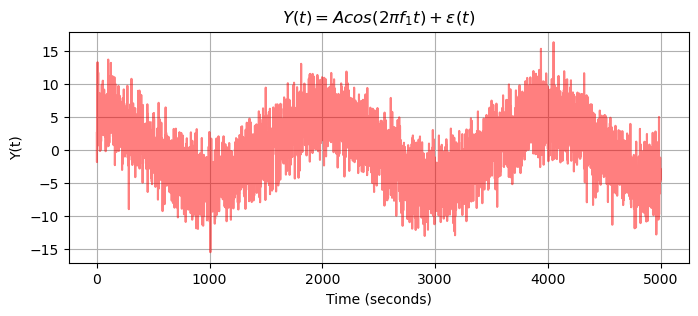

In [243]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
import math

sigma = 3          # Standard deviation of the noise
m = 5000            # Length of the time series
mean = 0

fs = 1             # Sampling frequency
time = 1/fs*np.arange(m)
f_1 = 0.0005
A = 5

et = np.random.normal(loc = mean, scale = sigma, size = m) # Noise
y =  A*np.cos(2 * np.pi*f_1 * time) + et  

plt.figure(figsize=(8,3))
plt.grid()
plt.plot(time, y, color='red',alpha = 0.5)
plt.ylabel('Y(t)')
plt.xlabel('Time (seconds)')
plt.title('$Y(t)$')
plt.title('$Y(t) = Acos(2 \pi f_1 t) + \epsilon(t) $');

Then, we apply the central, equal weighting Moving Average with $M=2$:

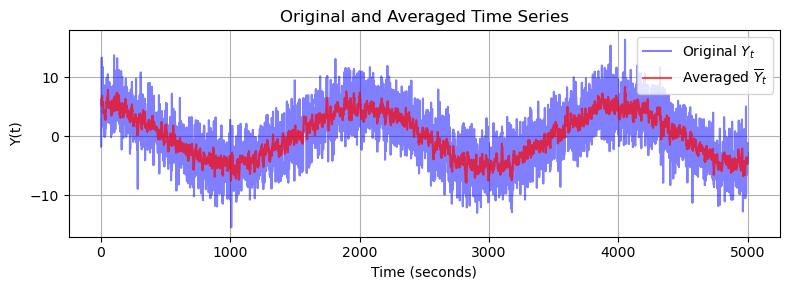

In [244]:
M = 4  # Moving average window (samples)
Y_bar = np.full(m, np.nan)  # Moving average signal
delta_Y = np.full(m, np.nan)  # Differenced signal

Y_bar2 = np.full(m, np.nan)  # Moving average signal
delta_Y2 = np.full(m, np.nan)  # Differenced signal

# Compute moving average and differenced signal (M = 4)
for t in range(M, len(y) - M):

    Y_bar[t] = np.mean(y[t-M:t+M+1])  # mean of previous M values
    delta_Y[t] = y[t] - Y_bar[t]

M_2 = M*5  # Moving average window (samples)
# Compute moving average and differenced signal (M = 20)
for t in range(M_2, len(y) - M_2):

    Y_bar2[t] = np.mean(y[t-M_2:t+M_2+1])  # mean of previous M values
    delta_Y2[t] = y[t] - Y_bar2[t]

# Plotting
plt.figure(figsize=(8,3))
plt.plot(time, y, label='Original $Y_t$', color='blue', alpha=0.5)
plt.plot(time, Y_bar, label='Averaged $\overline{Y}_t$', color='red',alpha=0.7)
plt.xlabel('Time (seconds)')
plt.ylabel('Y(t)')
plt.title('Original and Averaged Time Series')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

With $D(\epsilon)=\sigma^2=3^2=9$, the variance of the resulting time series reduces to $D(\bar{Y})=\frac{\sigma^2}{2M+1}=1$.
The noise reduction can be clearly seen in the previous figure of the time series, and the underlying seasonal cycle becomes (more) prominent.

The theoretical autocorrelation of the Moving average is expressed as

$$r_{\tau} = \sigma^2 (1-\frac{|\tau|}{2M+1})$$ 

for $|\tau| \leq 2M+1$ and the theoretical PSD is expressed as

$$S(f) = (2M+1) \sigma^2 \operatorname{sinc}^2((2M+1)f)$$

which hold for $\mu = 0$.


In the next code, the theoretical ACF and the theoretical PSD are computed for $M=4$ and $M=20$.

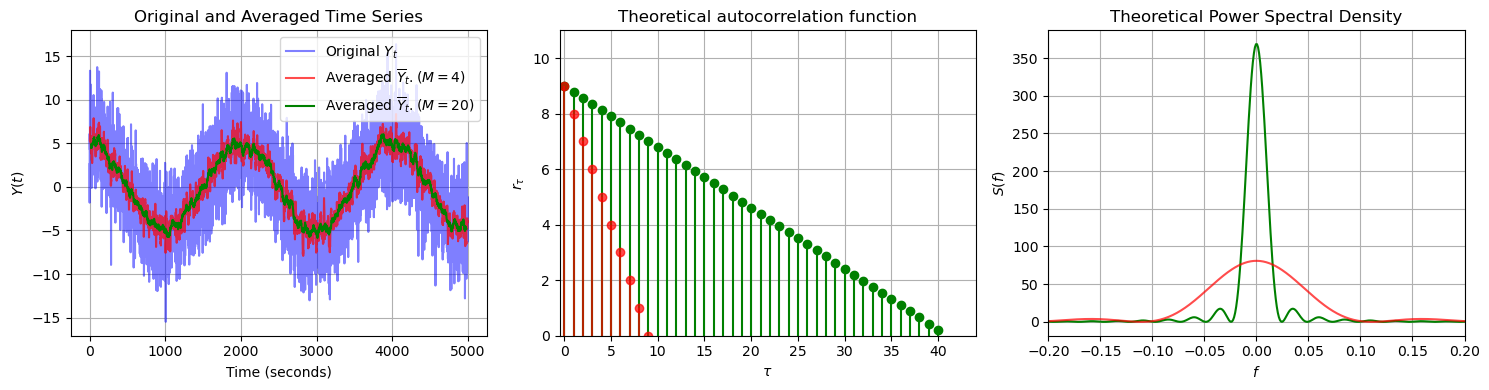

In [245]:
L =  2 * M + 1
L_2 =  2 * (M_2) + 1

# Generate tau values (lags)
taus = np.arange(-L_2 + 1, L_2)  # from -(L-1) to L-1

# Compute autocorrelation r_tau
r_tau = sigma**2 * (1 - np.abs(taus) / L)
r_tau_2 = sigma**2 * (1 - np.abs(taus) / L_2)

# Frequency axis
f = np.linspace(-0.5, 0.5, 1000)  # normalized frequency

# Power Spectral Density
S_f = L * sigma**2 * (np.sinc(L * f))**2
S_f_2 = L_2 * sigma**2 * (np.sinc(L_2 * f))**2

# Create figure with 1 row and 3 columns
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

# Time series plot
axs[0].plot(time, y, label='Original $Y_t$', color='b', alpha=0.5)
axs[0].plot(time, Y_bar, label='Averaged $\overline{Y}_t. (M = 4)$', color='red', alpha=0.7)
axs[0].plot(time, Y_bar2, label='Averaged $\overline{Y}_t. (M = 20)$', color='green')
axs[0].set_xlabel('Time (seconds)')
axs[0].set_ylabel(r'$Y(t)$')
axs[0].set_title('Original and Averaged Time Series')
axs[0].grid(True)
axs[0].legend()

# Autocorrelation plot
axs[1].stem(taus, r_tau_2, linefmt='g-', markerfmt='go', basefmt=' ')
markerline, stemlines, baseline = axs[1].stem(taus, r_tau, linefmt='r-', markerfmt='ro', basefmt=' ')
plt.setp(stemlines, alpha=0.7)
plt.setp(markerline, alpha=0.7)
axs[1].set_xlabel(r'$\tau$')
axs[1].set_ylabel(r'$r_{\tau}$')
axs[1].set_title('Theoretical autocorrelation function')
axs[1].grid(True)
axs[1].set_ylim(bottom=0)
axs[1].set_xlim(left=-0.5)

# PSD plot
axs[2].plot(f, S_f_2, color='green')
axs[2].plot(f, S_f, color='red', alpha=0.7)
axs[2].set_xlabel(r'$f$')
axs[2].set_ylabel(r'$S(f)$')
axs[2].set_title('Theoretical Power Spectral Density')
axs[2].grid(True)
axs[2].set_xlim(-0.2, 0.2)

plt.tight_layout()
plt.show()

In the time series plot, we can see that by increasing the window length from $M=4$ to $M=20$, the resulting moving average time series is less noisy. A larger windows size means that each averaged sample incorporates more surrounding data points, which increases the temporal correlation in the resulting time series. This behaviour is confirmed with the theoretical ACFs: the red ACF (for the shorter window) decays much quickly, while the green ACF (for the longer window) exhibits a slower decay.

In the plot of the theoretical PSDs for $M=4$ and $M=20$, we note that both spectra exhibit main peaks centered around zero frequency. This indicates that the moving average acts as a low pass filter, allowing only the low-frequency components of the original time series to pass through, while attenuating the high-frequency noise. As a result, the moving average retains the overall trend and smooths out rapid fluctuations. Note that for a larger window size (green line), the ACF is narrower. This shows that a larger window enhances the smoothing effect of the moving average, thus attenuating more high-frequency components.

filters out more high frequency components.


The following code plots the (nearly) stationary time series, which is computed as the difference between the original time series and the moving average:

$$
\Delta Y_t = Y_t -\overline{Y}_t
$$

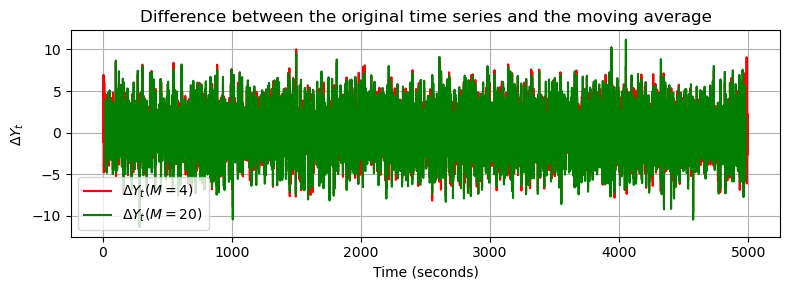

In [246]:
# Plotting
plt.figure(figsize=(8,3))
plt.plot(time, delta_Y, label=r'$\Delta Y_t (M= 4)$', color='red')
plt.plot(time, delta_Y2, label=r'$\Delta Y_t (M= 20)$', color='green')
plt.xlabel('Time (seconds)')
plt.ylabel(r'$\Delta Y_t$')
plt.title('Difference between the original time series and the moving average')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()